In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import scipy.io as sio
from dataclasses import dataclass
from typing import List, Tuple
import os
from dotenv import load_dotenv
load_dotenv()
import tidy3d as td
from tidy3d import web
import numpy as np
from pathlib import Path
from stl import mesh
import matplotlib.pyplot as plt
import re

In [2]:
import sys
import os

# Assuming /AutomationModule is in the root directory of your project
sys.path.append(os.path.abspath(rf'../../../../../tidy3d'))

from AutomationModule import * 

import AutomationModule as AM

In [3]:
tidy3dAPI = os.environ["API_TIDY3D_KEY"]


In [4]:
# Function to create a solid cylinder with specified center coordinates
def create_cylinder_from_ends(top_center, bottom_center, radius):
    # Calculate height of the cylinder
    height = np.linalg.norm(np.array(top_center) - np.array(bottom_center))
    bottom_center=bottom_center

    # Calculate the vector direction of the cylinder
    axis_direction = np.array(top_center) - np.array(bottom_center)
    axis_direction /= np.linalg.norm(axis_direction) #Unitary vector to calculate rotation angle 

    # Calculate the rotation matrix to align cylinder with the given axis direction
    z_axis = np.array([0, 0, 1])
    rotation_axis = np.cross(z_axis, axis_direction)
    rotation_angle = np.arccos(np.dot(z_axis, axis_direction))
    rotation_matrix = mesh.Mesh.rotation_matrix(rotation_axis, rotation_angle)
    # Create a 4x4 identity matrix
    matrix_4x4 = np.eye(4)

    # Insert the 3x3 matrix into the top-left corner of the new matrix
    matrix_4x4[:3, :3] = np.copy(rotation_matrix)

    # Set the fourth column and fourth row for homogeneous transformation
    # The typical homogeneous transformation uses [0, 0, 0, 1] for the last row and column
    matrix_4x4[3, :3] = [0, 0, 0]  # Fourth row
    matrix_4x4[:3, 3] = [0, 0, 0]  # Fourth column
    matrix_4x4[3, 3] = 1           # Bottom-right corner remains 1

    
   
    cylinder_center = tuple((np.array(top_center) + np.array(bottom_center))/2)
    trans = td.Transformed.translation(cylinder_center[0],cylinder_center[1],cylinder_center[2])
    transformed = td.Transformed(geometry=td.Cylinder(center=(0,0,0), radius=radius, length=height),transform=trans@matrix_4x4)

    return transformed

In [5]:
a=2.562629142772549
lambda_ranges =[[8,2.5]]
lambda_ranges

[[8, 2.5]]

In [6]:
n_eff=1
run = False

18:24:02 W. Europe Daylight Time WARNING: Structure at 'structures[1]' has      
                                 bounds that extend exactly to simulation edges.
                                 This can cause unexpected behavior. If         
                                 intending to extend the structure to infinity  
                                 along one dimension, use td.inf as a size      
                                 variable instead to make this explicit.        

                                 WARNING: Suppressed 1 WARNING message.         

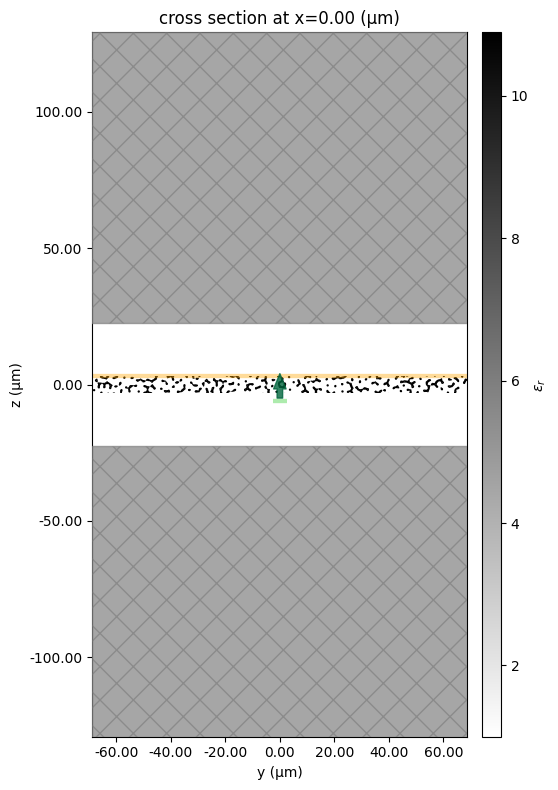

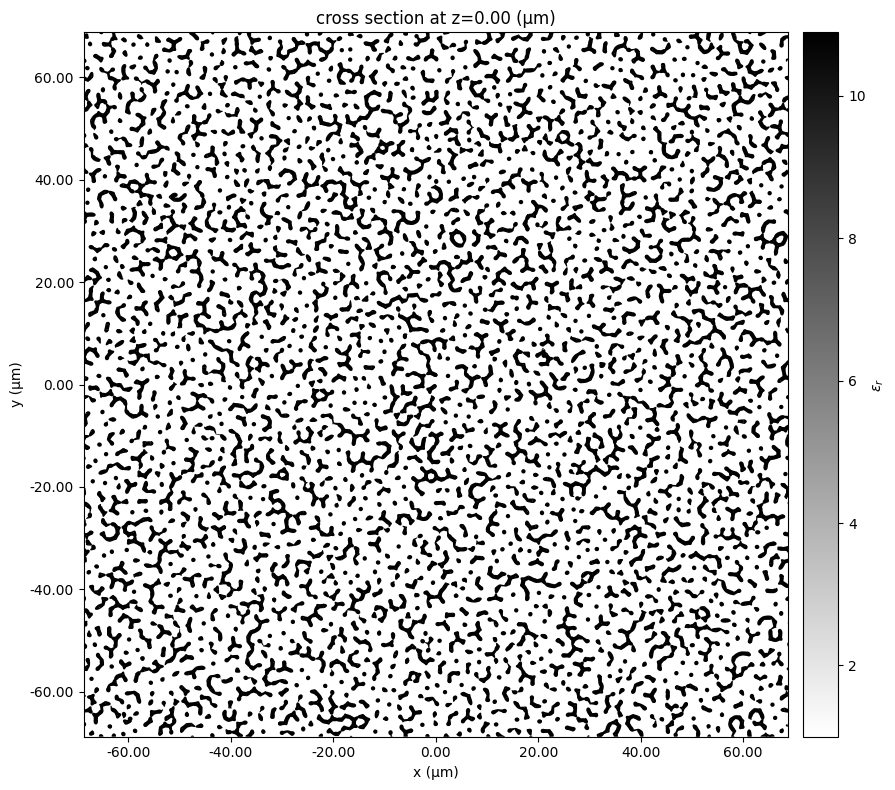

Error processing ../Structures: upload() missing 1 required positional argument: 'task_name'


In [7]:
folder_path = rf"../Structures"
project_name = "20260727_Beam_Spreading_110_110_12_freqs_1700"
postprocess_results = []
runtimes_ps = [20e-12]*3
min_steps_per_lambda = 15
t_slabx, t_slaby, t_slabz = 137.5, 137.5, 12
cuts=[1]
h5_bg = None
ref = False
for l,lambdas in enumerate(lambda_ranges): 
    for dirpath, dirnames, filenames in os.walk(folder_path):
        try:
            for filename in filenames:
                if filename.endswith(".txt"):
                    for cut in cuts:
                        if os.path.isfile(os.path.join(dirpath, filename)):
                            file=os.path.join(dirpath, filename)
                           


                            data = []
                            with open(file, 'r') as file:
                                for line in file: 
                                    row = [float(value) for value in line.split()]
                                    data += [np.array(row)]

                            data = np.array(data)

                            tops = (data[:,:3])/0.8
                            bottoms = (data[:,3:])/0.8
                            radius = 0.42


                            cyl_group = []
                            
                            for cil,item in enumerate(tops):
                                cyl_group.append(create_cylinder_from_ends(tops[cil], bottoms[cil], radius))

                            medium=td.Medium(permittivity=3.3**2)
                            structure = td.Structure(geometry=td.GeometryGroup(geometries=cyl_group),  medium=medium)
                            Lx, Ly, Lz =t_slabx, t_slaby, 45


                            
                            f_min, f_max = td.C_0/lambdas[0], td.C_0/lambdas[1]
                            f0 = (f_min + f_max) / 2
                            source_def = td.PlaneWave(
                                source_time = td.GaussianPulse(
                                    freq0=f0,
                                    fwidth=0.5*(f_max - f_min),
                                    offset=10,
                                    phase=0
                                ),
                                size= (5, 
                                      5, 
                                      0) 
                                      ,
                                center=( 0, 
                                         0, 
                                        (-t_slabz/2)-3),
                                direction='+',
                                name='planewave',
                                )
                            
                            freq_range = td.C_0/np.array(lambdas)
                            
                            monitor_freqs = np.linspace(freq_range[0],freq_range[1],1700)
                            
                            monitorField_exit = td.FieldMonitor(
                                    center=[0,0,t_slabz/2],
                                    size=[
                                            Lx,
                                            Ly,
                                            0
                                        ],
                                    interval_space = (3,3,3),

                                    fields=["Ex", "Ey", "Ez"],
                                    freqs=monitor_freqs,
                                    name="monitorField_exit",
                                )
                            
                            dl = (lambdas[1] /min_steps_per_lambda) / 3.3 #  grids per smallest wavelength in medium
                            boundaries= td.BoundarySpec(
                                x= td.Boundary.periodic(),
                                y=td.Boundary.periodic(),
                                z=td.Boundary(plus=td.Absorber(num_layers=200),minus=td.Absorber(num_layers=200))
                            )
                            cube1 = td.Structure(geometry= td.Box(
                                center=(0,  0 , -(Lz/2+t_slabz/2)/2),
                                size=(
                                        td.inf, 
                                        td.inf, 
                                        Lz/2-t_slabz/2
                                      ),
                                ),medium=td.Medium(permittivity=1))
                            cube2 = td.Structure(geometry= td.Box(
                                center=(0,  0 , (Lz/2+t_slabz/2)/2),
                                size=(
                                        td.inf, 
                                        td.inf, 
                                        Lz/2-t_slabz/2
                                      ),
                                ),medium=td.Medium(permittivity=1))
                            sim = td.Simulation(
                                center = (0, 0, 0),
                                size = (Lx, Ly, Lz),
                                grid_spec = td.GridSpec.auto(min_steps_per_wvl=min_steps_per_lambda,wavelength=lambdas[0],
                                            dl_min=dl,
                                            max_scale=1.2),
                                sources = [source_def],
                                monitors = [monitorField_exit],
                                run_time = runtimes_ps[l],
                                shutoff =1e-20, #Simulation stops when field has decayed to this 
                                boundary_spec = boundaries,
                                normalize_index = None,
                                structures = [structure,cube1,cube2],
                                subpixel=True,
                                medium=td.Medium(permittivity=1)


                                )
                            fig, ax = plt.subplots(1, tight_layout=True, figsize=(16, 8))
                            freqs_plot = (freq_range[0], freq_range[1])
                            sim.plot_eps(x=0, freq=freqs_plot[0], ax=ax)
                            plt.show()
                            fig, ax = plt.subplots(1, tight_layout=True, figsize=(16, 8))
                            freqs_plot = (freq_range[0], freq_range[1])
                            sim.plot_eps(z=0, freq=freqs_plot[0], ax=ax)
                            plt.show()



                            if run:
                                folder_desc = rf"../../../../data/{project_name}/n_{3.3:.2f}"
                                os.makedirs(folder_desc, exist_ok=True)
                                sim_name=rf"LSU_{Path(filename).stem}_size_{cut}_lambda_{lambdas[1]}_{lambdas[0]}"
                                if os.path.exists(os.path.join(folder_desc, sim_name+".txt")):
                                    print("Exist!")
                                else:
                                    id =web.upload(sim, folder_name=project_name,task_name=sim_name, verbose=True)
                                    ids = '\n' + id
                                    with open(os.path.join(folder_desc, sim_name+".txt"), "w") as file:
                                        # Write the string to the file
                                        file.write(ids)
                                    web.start(task_id = id)
                                    web.monitor(id)
                            else: 
                                id =web.upload(sim, verbose=True) 
                                web.estimate_cost(id)  

        except Exception as e:
            print(f"Error processing {dirpath}: {e}")

        
